In [1]:
!pip install -q transformers datasets accelerate torch scikit-learn pandas numpy matplotlib seaborn nltk wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)

from datasets import Dataset

nltk.download('stopwords')
from nltk.corpus import stopwords

print("Libraries loaded successfully!")

Libraries loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
data = {
    "review": [
        "The battery range is excellent and the charging is very fast.",
        "The engine performance is amazing and the mileage is very good.",
        "The car is comfortable and the interior quality is excellent.",
        "The safety features are impressive and I feel very secure.",
        "The infotainment system is smooth and easy to use.",
        "The service experience was excellent and the staff was helpful.",
        "The price is reasonable considering the features provided.",
        "The battery range is poor and charging takes too long.",
        "The engine is noisy and the mileage is disappointing.",
        "The seats are uncomfortable during long journeys.",
        "The braking performance is terrible and feels unsafe.",
        "The infotainment system is slow and frequently crashes.",
        "The service center was disappointing and staff were unhelpful.",
        "The car is too expensive for the features it offers.",
        "The battery performance is good but charging time is too long.",
        "Mileage is excellent but the interior quality is poor.",
        "The car looks beautiful and driving experience is fantastic.",
        "The suspension is comfortable but braking needs improvement.",
        "The vehicle has excellent safety features.",
        "The charging infrastructure is disappointing.",
        "The engine delivers excellent performance.",
        "Fuel consumption is higher than expected.",
        "The seats are extremely comfortable.",
        "The air conditioning works perfectly.",
        "The infotainment screen is very responsive.",
        "The service was slow and frustrating.",
        "The build quality feels premium.",
        "The car offers poor mileage.",
        "The battery charges quickly and provides excellent range.",
        "The price is too high."
    ],

    "sentiment": [
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "positive",
        "positive",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "positive",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative"
    ]
}

df = pd.DataFrame(data)

df.head()

,review,sentiment
0,The battery range is excellent and the chargin...,positive
1,The engine performance is amazing and the mile...,positive
2,The car is comfortable and the interior qualit...,positive
3,The safety features are impressive and I feel ...,positive
4,The infotainment system is smooth and easy to ...,positive


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

Dataset Shape: (30, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Sentiment Distribution:
sentiment
positive    16
negative    14
Name: count, dtype: int64


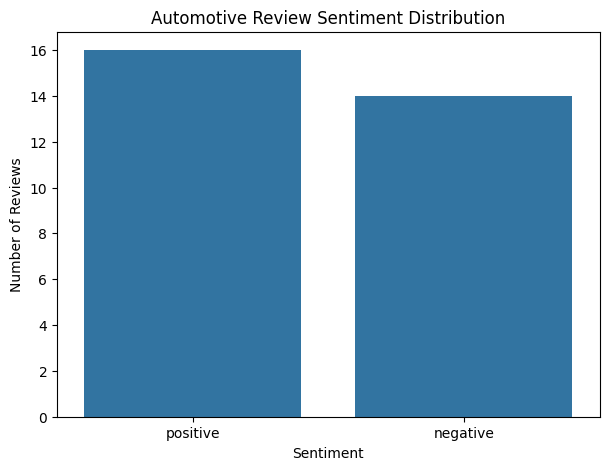

In [5]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Automotive Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [6]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,The battery range is excellent and the chargin...,the battery range is excellent and the chargin...
1,The engine performance is amazing and the mile...,the engine performance is amazing and the mile...
2,The car is comfortable and the interior qualit...,the car is comfortable and the interior qualit...
3,The safety features are impressive and I feel ...,the safety features are impressive and i feel ...
4,The infotainment system is smooth and easy to ...,the infotainment system is smooth and easy to use


In [7]:
label_mapping = {
    "negative": 0,
    "positive": 1
}

df["label"] = df["sentiment"].map(label_mapping)

df.head()

,review,sentiment,clean_review,label
0,The battery range is excellent and the chargin...,positive,the battery range is excellent and the chargin...,1
1,The engine performance is amazing and the mile...,positive,the engine performance is amazing and the mile...,1
2,The car is comfortable and the interior qualit...,positive,the car is comfortable and the interior qualit...,1
3,The safety features are impressive and I feel ...,positive,the safety features are impressive and i feel ...,1
4,The infotainment system is smooth and easy to ...,positive,the infotainment system is smooth and easy to use,1


In [8]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 24
Testing samples: 6


In [9]:
train_dataset = Dataset.from_pandas(
    train_df[["clean_review", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["clean_review", "label"]]
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['clean_review', 'label', '__index_level_0__'],
    num_rows: 24
})
Dataset({
    features: ['clean_review', 'label', '__index_level_0__'],
    num_rows: 6
})


In [10]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [11]:
def tokenize_function(examples):
    return tokenizer(
        examples["clean_review"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print(tokenized_train)

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

Dataset({
    features: ['clean_review', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 24
})


In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print("BERT-based model loaded!")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT-based model loaded!


In [13]:
id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

model.config.id2label = id2label
model.config.label2id = label2id

In [15]:
training_args = TrainingArguments(
    output_dir="./automotive_sentiment_model",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    report_to="none"
)

In [17]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy
    }

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

In [19]:
trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.705347,0.500000
2,No log,0.693819,0.500000
3,No log,0.689223,0.500000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9, training_loss=0.6803589397006564, metrics={'train_runtime': 71.0164, 'train_samples_per_second': 1.014, 'train_steps_per_second': 0.127, 'total_flos': 2384413175808.0, 'train_loss': 0.6803589397006564, 'epoch': 3.0})

In [20]:
results = trainer.evaluate()

print("Evaluation Results:")
print(results)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.689223,3,0.500000


Evaluation Results:
{'eval_loss': 0.689222514629364, 'eval_accuracy': 0.5}


In [21]:
predictions = trainer.predict(tokenized_test)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

actual_labels = predictions.label_ids

print("Predicted Labels:")
print(predicted_labels)

print("\nActual Labels:")
print(actual_labels)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicted Labels:
[1 1 1 1 1 1]

Actual Labels:
[0 1 0 1 0 1]


In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


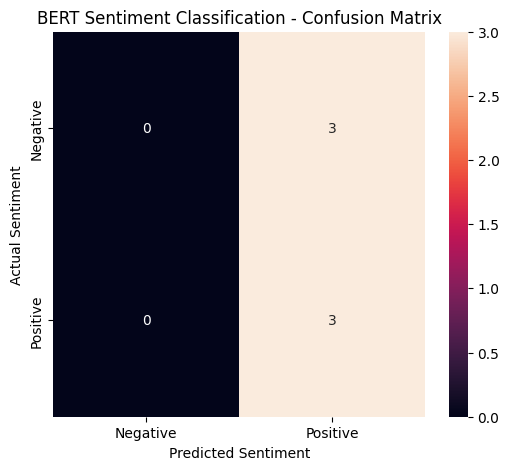

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("BERT Sentiment Classification - Confusion Matrix")

plt.show()

In [24]:
model.save_pretrained(
    "./automotive_sentiment_model"
)

tokenizer.save_pretrained(
    "./automotive_sentiment_model"
)

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [25]:
def predict_sentiment(review):

    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    prediction = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[0][prediction].item()

    if prediction == 0:
        sentiment = "NEGATIVE"
    else:
        sentiment = "POSITIVE"

    return sentiment, confidence

In [26]:
review = "The battery range is excellent but charging takes too long."

sentiment, confidence = predict_sentiment(review)

print("Review:")
print(review)

print("\nSentiment:", sentiment)
print("Confidence:", round(confidence * 100, 2), "%")

Review:
The battery range is excellent but charging takes too long.

Sentiment: POSITIVE
Confidence: 54.65 %


In [27]:
aspects = {
    "Vehicle": [
        "car",
        "vehicle"
    ],

    "Engine": [
        "engine",
        "motor"
    ],

    "Battery": [
        "battery"
    ],

    "Mileage": [
        "mileage",
        "fuel consumption"
    ],

    "Safety": [
        "safety",
        "braking",
        "brake"
    ],

    "Comfort": [
        "comfort",
        "comfortable",
        "seat",
        "seats",
        "suspension"
    ],

    "Service": [
        "service",
        "service center"
    ],

    "Infotainment": [
        "infotainment",
        "screen"
    ],

    "Price": [
        "price",
        "expensive",
        "cost"
    ],

    "Charging": [
        "charging",
        "charge"
    ],

    "Range": [
        "range"
    ]
}

In [28]:
def extract_aspects(review):

    review_lower = review.lower()

    detected_aspects = []

    for aspect, keywords in aspects.items():

        for keyword in keywords:

            if keyword in review_lower:
                detected_aspects.append(aspect)
                break

    return detected_aspects

In [29]:
review = "The battery range is excellent but charging takes too long."

print(extract_aspects(review))

['Battery', 'Charging', 'Range']


In [30]:
import re

def split_sentences(text):

    sentences = re.split(
        r'(?<=[.!?])\s+',
        text
    )

    return sentences

In [31]:
def aspect_sentiment(review):

    sentences = split_sentences(review)

    results = []

    for sentence in sentences:

        detected_aspects = extract_aspects(sentence)

        if not detected_aspects:
            continue

        sentiment, confidence = predict_sentiment(sentence)

        for aspect in detected_aspects:

            results.append({
                "Aspect": aspect,
                "Sentiment": sentiment,
                "Confidence": round(confidence * 100, 2),
                "Sentence": sentence
            })

    return pd.DataFrame(results)

In [32]:
review = "The battery range is excellent, but the charging time is too long."

result = aspect_sentiment(review)

result

,Aspect,Sentiment,Confidence,Sentence
0,Battery,POSITIVE,54.67,"The battery range is excellent, but the chargi..."
1,Charging,POSITIVE,54.67,"The battery range is excellent, but the chargi..."
2,Range,POSITIVE,54.67,"The battery range is excellent, but the chargi..."


In [33]:
def analyze_review(review):

    print("=" * 60)
    print("AUTOMOTIVE REVIEW & SENTIMENT ANALYZER")
    print("=" * 60)

    print("\nReview:")
    print(review)

    # Overall sentiment
    sentiment, confidence = predict_sentiment(review)

    print("\nOverall Sentiment:")
    print(sentiment)

    print(
        "Confidence:",
        round(confidence * 100, 2),
        "%"
    )

    # Aspect analysis
    result = aspect_sentiment(review)

    print("\nAspect-Level Sentiment:")

    if result.empty:

        print("No automotive aspect detected.")

    else:

        display(
            result[
                ["Aspect", "Sentiment", "Confidence"]
            ]
        )

    print("=" * 60)

    return result

In [34]:
review = """
The battery range is excellent, but the charging time is too long.
The seats are comfortable and the infotainment system is responsive.
However, the price is too high.
"""

result = analyze_review(review)

AUTOMOTIVE REVIEW & SENTIMENT ANALYZER

Review:

The battery range is excellent, but the charging time is too long.
The seats are comfortable and the infotainment system is responsive.
However, the price is too high.


Overall Sentiment:
POSITIVE
Confidence: 54.14 %

Aspect-Level Sentiment:


,Aspect,Sentiment,Confidence
0,Battery,POSITIVE,54.67
1,Charging,POSITIVE,54.67
2,Range,POSITIVE,54.67
3,Comfort,POSITIVE,54.47
4,Infotainment,POSITIVE,54.47
5,Price,POSITIVE,53.53


In [35]:
review = """
The engine performance is excellent and the mileage is impressive.
However, the service center is slow and disappointing.
"""

analyze_review(review)

AUTOMOTIVE REVIEW & SENTIMENT ANALYZER

Review:

The engine performance is excellent and the mileage is impressive.
However, the service center is slow and disappointing.


Overall Sentiment:
POSITIVE
Confidence: 53.19 %

Aspect-Level Sentiment:


,Aspect,Sentiment,Confidence
0,Engine,POSITIVE,56.44
1,Mileage,POSITIVE,56.44
2,Service,POSITIVE,51.83


,Aspect,Sentiment,Confidence,Sentence
0,Engine,POSITIVE,56.44,\nThe engine performance is excellent and the ...
1,Mileage,POSITIVE,56.44,\nThe engine performance is excellent and the ...
2,Service,POSITIVE,51.83,"However, the service center is slow and disapp..."


In [36]:
review = """
The battery range is poor and charging takes too long.
The seats are uncomfortable but the price is reasonable.
"""

analyze_review(review)

AUTOMOTIVE REVIEW & SENTIMENT ANALYZER

Review:

The battery range is poor and charging takes too long.
The seats are uncomfortable but the price is reasonable.


Overall Sentiment:
POSITIVE
Confidence: 53.29 %

Aspect-Level Sentiment:


,Aspect,Sentiment,Confidence
0,Battery,POSITIVE,53.09
1,Charging,POSITIVE,53.09
2,Range,POSITIVE,53.09
3,Comfort,POSITIVE,52.85
4,Price,POSITIVE,52.85


,Aspect,Sentiment,Confidence,Sentence
0,Battery,POSITIVE,53.09,\nThe battery range is poor and charging takes...
1,Charging,POSITIVE,53.09,\nThe battery range is poor and charging takes...
2,Range,POSITIVE,53.09,\nThe battery range is poor and charging takes...
3,Comfort,POSITIVE,52.85,The seats are uncomfortable but the price is r...
4,Price,POSITIVE,52.85,The seats are uncomfortable but the price is r...


In [37]:
review = """
The safety features are excellent and the infotainment system
is very responsive. The car is comfortable and offers good mileage.
"""

analyze_review(review)

AUTOMOTIVE REVIEW & SENTIMENT ANALYZER

Review:

The safety features are excellent and the infotainment system
is very responsive. The car is comfortable and offers good mileage.


Overall Sentiment:
POSITIVE
Confidence: 56.23 %

Aspect-Level Sentiment:


,Aspect,Sentiment,Confidence
0,Safety,POSITIVE,56.32
1,Infotainment,POSITIVE,56.32
2,Vehicle,POSITIVE,55.55
3,Mileage,POSITIVE,55.55
4,Comfort,POSITIVE,55.55


,Aspect,Sentiment,Confidence,Sentence
0,Safety,POSITIVE,56.32,\nThe safety features are excellent and the in...
1,Infotainment,POSITIVE,56.32,\nThe safety features are excellent and the in...
2,Vehicle,POSITIVE,55.55,The car is comfortable and offers good mileage.
3,Mileage,POSITIVE,55.55,The car is comfortable and offers good mileage.
4,Comfort,POSITIVE,55.55,The car is comfortable and offers good mileage.


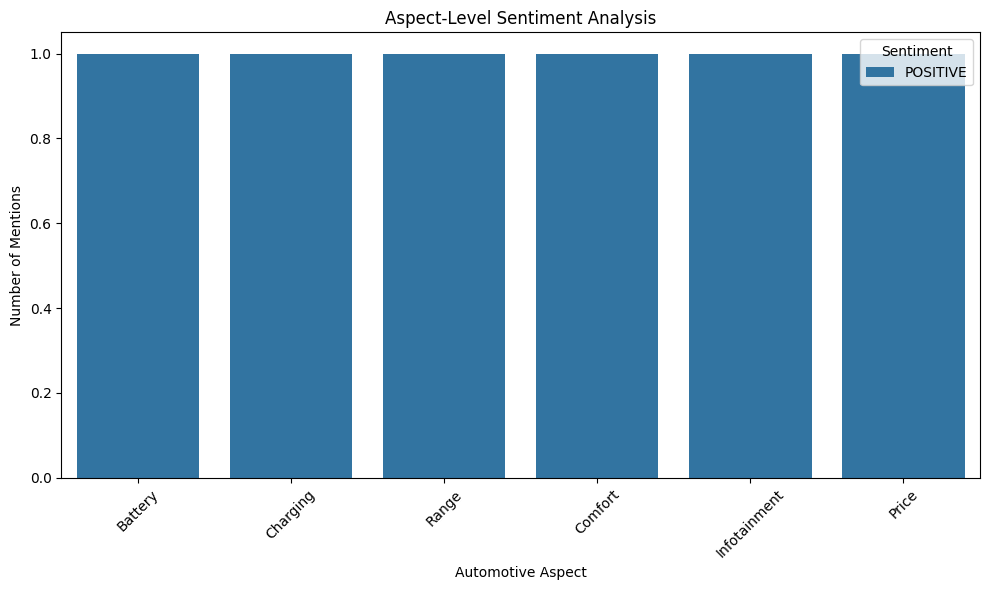

In [38]:
if not result.empty:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=result,
        x="Aspect",
        hue="Sentiment"
    )

    plt.title("Aspect-Level Sentiment Analysis")

    plt.xlabel("Automotive Aspect")
    plt.ylabel("Number of Mentions")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

In [39]:
user_review = input(
    "Enter an automotive review: "
)

analyze_review(user_review)

Enter an automotive review: 50
AUTOMOTIVE REVIEW & SENTIMENT ANALYZER

Review:
50

Overall Sentiment:
POSITIVE
Confidence: 55.77 %

Aspect-Level Sentiment:
No automotive aspect detected.


""
